# ICP with Explicit Rotation/Translation Equations

Each ICP iteration alternates:
1. nearest-neighbor assignment,
2. rigid Procrustes solve
$$
\min_{R,t}\sum_i \|R x_i + t - y_{\pi(i)}\|^2,\quad R\in SO(2),
$$
with $R = UV^\top$ from SVD of centered cross-covariance.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
th = np.linspace(0, 2*np.pi, 80, endpoint=False)
Y = np.c_[np.cos(th)+0.2*np.cos(3*th), 0.8*np.sin(th)]
R0 = np.array([[np.cos(0.5), -np.sin(0.5)], [np.sin(0.5), np.cos(0.5)]])
X = (Y @ R0.T) + np.array([0.6, -0.25])


## ICP iterations


In [2]:
Xs = [X.copy()]
for _ in range(35):
    D = np.sum((X[:,None,:]-Y[None,:,:])**2, axis=2)
    j = np.argmin(D, axis=1)
    Yj = Y[j]
    mx, my = X.mean(axis=0), Yj.mean(axis=0)
    Xc, Yc = X-mx, Yj-my
    H = Xc.T @ Yc
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1,:] *= -1
        R = Vt.T @ U.T
    t = my - R @ mx
    Xnew = (X @ R.T) + t
    X = Xnew
    Xs.append(X.copy())
Xs = np.array(Xs)


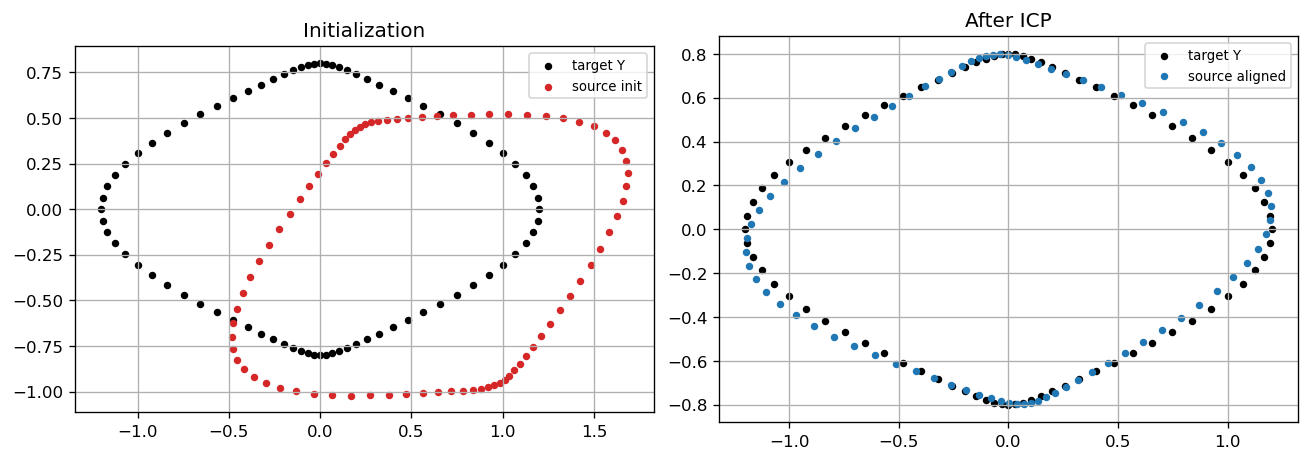

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3), constrained_layout=True)
axes[0].scatter(Y[:,0], Y[:,1], s=12, c='k', label='target Y')
axes[0].scatter(Xs[0,:,0], Xs[0,:,1], s=12, c='tab:red', label='source init')
axes[0].set_title('Initialization')
axes[1].scatter(Y[:,0], Y[:,1], s=12, c='k', label='target Y')
axes[1].scatter(Xs[-1,:,0], Xs[-1,:,1], s=12, c='tab:blue', label='source aligned')
axes[1].set_title('After ICP')
for ax in axes:
    ax.set_aspect('equal'); ax.legend(fontsize=8)
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()


## Interactive: slowed path with interpolation factor tau
